# Анализ Turbovec для классификации изображений

Пайплайн анализа:
1. Загрузка результатов бенчмарка (baseline и turbovec bw=2/bw=4, для k=5 и k=10)
2. Объединение всех прогонов в общую таблицу
3. Для каждой конфигурации (k, bit_width) подсчитать и провизуализировать (line chart):
- Accuracy
- Top-5 Accuracy
- F1 macro
- F1 weighted
4. Бутстрап доверительных интервалов
5. McNemar тест для multiclass classification
6. Forest plot (главный график со сводной информацией)

In [39]:
# Утилиты
from pathlib import Path
import re
import json
RESULTS_DIR = str(Path.cwd().parent / "results/image_classification")
RESULTS_DIR = RESULTS_DIR.replace('\\', '/') + '/'

In [38]:
# Библиотеки для анализа данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar

## 1. Загрузка данных выборочно

In [23]:
tv_bw2_k10 = pd.read_csv(RESULTS_DIR + 'turbovec_bw2_k10_20260703_092749.csv')
bl_k10 = pd.read_csv(RESULTS_DIR + 'baseline_k10_20260703_092749.csv')

In [24]:
tv_bw2_k10.head()

,test_id,image_path,true_label,true_breed,pred_label,pred_breed,time_ms
0,1,C:\Users\Honor\test_turbovec\data\image_classi...,0,Abyssinian,0,Abyssinian,88.760376
1,2,C:\Users\Honor\test_turbovec\data\image_classi...,0,Abyssinian,0,Abyssinian,2.415180
2,3,C:\Users\Honor\test_turbovec\data\image_classi...,0,Abyssinian,0,Abyssinian,2.760410
3,4,C:\Users\Honor\test_turbovec\data\image_classi...,0,Abyssinian,0,Abyssinian,2.529383
4,5,C:\Users\Honor\test_turbovec\data\image_classi...,0,Abyssinian,5,Bengal,2.426624


In [25]:
tv_bw2_k10.describe()

,test_id,true_label,pred_label,time_ms
count,3669.000000,3669.000000,3669.000000,3669.000000
mean,1835.000000,18.002998,17.743254,2.330380
std,1059.293397,10.655876,10.653128,1.496536
min,1.000000,0.000000,0.000000,1.404524
25%,918.000000,9.000000,8.000000,1.944065
50%,1835.000000,18.000000,18.000000,2.218723
75%,2752.000000,27.000000,27.000000,2.608776
max,3669.000000,36.000000,36.000000,88.760376


In [26]:
bl_k10.describe()

,test_id,true_label,pred_label,time_ms
count,3669.000000,3669.000000,3669.000000,3669.000000
mean,1835.000000,18.002998,17.750886,1.467006
std,1059.293397,10.655876,10.670722,0.353480
min,1.000000,0.000000,0.000000,0.796556
25%,918.000000,9.000000,8.000000,1.276970
50%,1835.000000,18.000000,18.000000,1.432419
75%,2752.000000,27.000000,27.000000,1.605988
max,3669.000000,36.000000,36.000000,15.904427


## 2. Группировка таблиц

In [40]:
frames = []

for file in Path(RESULTS_DIR).glob("*.csv"):
    name = file.stem

    if name.startswith("baseline"):
        method = "baseline"
        bit_width = np.nan
    else:
        method = "turbovec"
        bit_width = int(re.search(r"bw(\d+)", name).group(1))

    k = int(re.search(r"k(\d+)", name).group(1))

    run_id = name.split("_")[-2] + "_" + name.split("_")[-1]

    df = pd.read_csv(file)

    df["method"] = method
    df["bit_width"] = bit_width
    df["k"] = k
    df["run_id"] = run_id

    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

all_df["variant"] = np.where(
    all_df.method=="baseline",
    "baseline",
    "turbovec_bw"+all_df.bit_width.astype("Int64").astype(str)
)

In [28]:
all_df.tail()

,test_id,image_path,true_label,true_breed,pred_label,pred_breed,time_ms,method,bit_width,k,run_id,variant
141109,19846,NaN,99,NaN,99,NaN,0.673294,turbovec,4.0,5,20260706_170409,turbovec_bw4
141110,19847,NaN,99,NaN,99,NaN,1.001358,turbovec,4.0,5,20260706_170409,turbovec_bw4
141111,19848,NaN,99,NaN,99,NaN,0.663042,turbovec,4.0,5,20260706_170409,turbovec_bw4
141112,19849,NaN,99,NaN,99,NaN,0.631571,turbovec,4.0,5,20260706_170409,turbovec_bw4
141113,19850,NaN,99,NaN,99,NaN,0.948906,turbovec,4.0,5,20260706_170409,turbovec_bw4


## 3. Вычисление метрик

In [41]:
summaries = {}
for f in sorted(Path(RESULTS_DIR).glob("summary_*.json")):
    s = json.loads(f.read_text())
    summaries[s["run_id"]] = s

def top5_res(run_id, variant):
    s = summaries[run_id]
    if variant == "baseline":
        return s["baseline"]["top5_accuracy"]
    bw = int(variant.split("bw")[1])
    return next(t["top5_accuracy"] for t in s["turbovec"] if t["bit_width"] == bw)

def compute_metrics(sub):
    run_id = sub["run_id"].iloc[0]
    k = sub["k"].iloc[0]
    bit_width = sub["bit_width"].iloc[0]
    accuracy = accuracy_score(sub["true_label"], sub["pred_label"])
    macro_f1 = f1_score(sub["true_label"], sub["pred_label"], average="macro")
    weighted_f1 = f1_score(sub["true_label"], sub["pred_label"], average="weighted")
    top5 = top5_res(run_id, sub["variant"].iloc[0])
    return (run_id, k, bit_width, accuracy, macro_f1, weighted_f1, top5)

metrics_df = pd.DataFrame(
    [compute_metrics(sub) + (variant, summaries[run_id]["num_classes"])
     for (run_id, k, variant), sub in all_df.groupby(["run_id", "k", "variant"])],
    columns=["run_id", "k", "bit_width", "accuracy", "macro_f1", "weighted_f1",
             "top5_accuracy", "variant", "n_classes"],
)
metrics_df.round(4)

,run_id,k,bit_width,accuracy,macro_f1,weighted_f1,top5_accuracy,variant,n_classes
0,20260703_091929,5,NaN,0.9005,0.8994,0.9002,0.9681,baseline,37
1,20260703_091929,5,2.0,0.9016,0.9001,0.9009,0.9687,turbovec_bw2,37
2,20260703_091929,5,4.0,0.8997,0.8985,0.8994,0.9700,turbovec_bw4,37
3,20260703_092749,10,NaN,0.9076,0.9065,0.9071,0.9681,baseline,37
4,20260703_092749,10,2.0,0.9084,0.9072,0.9079,0.9687,turbovec_bw2,37
5,20260703_092749,10,4.0,0.9065,0.9055,0.9060,0.9700,turbovec_bw4,37
6,20260706_170409,5,NaN,0.6767,0.6724,0.6724,0.8623,baseline,397
7,20260706_170409,5,2.0,0.6805,0.6764,0.6764,0.8622,turbovec_bw2,397
8,20260706_170409,5,4.0,0.6769,0.6730,0.6730,0.8605,turbovec_bw4,397
9,20260706_180758,10,NaN,0.6868,0.6812,0.6812,0.8623,baseline,397


### График

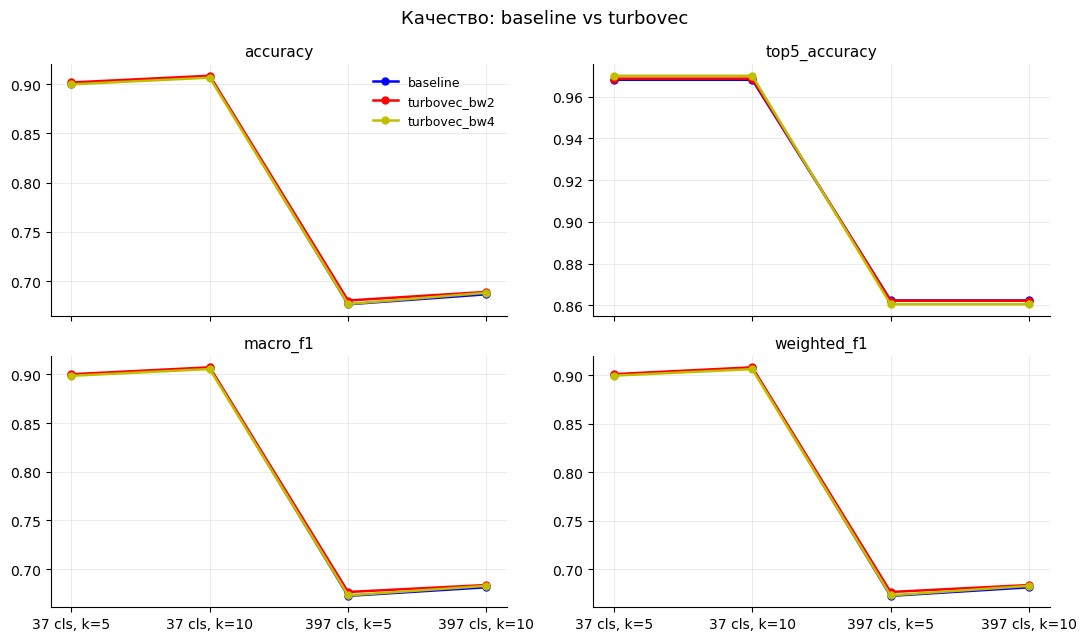

In [32]:
COLORS = {"baseline": "b", "turbovec_bw2": "r", "turbovec_bw4": "y"}
METRIC_COLS = ["accuracy", "top5_accuracy", "macro_f1", "weighted_f1"]

plot_df = metrics_df.sort_values(["n_classes", "k"]).copy()
plot_df["config"] = plot_df["n_classes"].astype(str) + " cls, k=" + plot_df["k"].astype(str)
order = plot_df["config"].drop_duplicates().tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, metric in zip(axes.ravel(), METRIC_COLS):
    for variant, color in COLORS.items():
        sub = plot_df[plot_df["variant"] == variant].set_index("config").reindex(order)
        ax.plot(order, sub[metric], marker="o", ms=5, lw=1.8, color=color, label=variant)
    ax.set_title(metric, fontsize=11)
    ax.grid(alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Качество: baseline vs turbovec", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Бутстрап доверительных интервалов

In [33]:
def bootstrap_ci(sample, theta_func, alpha=0.05, B=1000, random_state=None, return_samples=False):
    if random_state is not None:
        np.random.seed(random_state)

    N = len(sample)
    theta_estim = theta_func(sample)

    theta_asterisk_array = []
    for _ in range(B):
        bootstrap_sample = np.random.choice(sample, replace=True, size=N)
        theta_asterisk = theta_func(bootstrap_sample)
        theta_asterisk_array.append(theta_asterisk)
    theta_asterisk_array = np.array(theta_asterisk_array)

    left_theta_asterisk, right_theta_asterisk = np.quantile(theta_asterisk_array, [alpha / 2, 1 - alpha / 2])
    left_bound = 2 * theta_estim - right_theta_asterisk
    right_bound = 2 * theta_estim - left_theta_asterisk

    if return_samples:
        return left_bound, right_bound, theta_estim, theta_asterisk_array
    return left_bound, right_bound


def compute_metric_diff_bootstrap(df, run_id, k, bit_width, metric='accuracy', alpha=0.05, B=1000, random_state=42):
    sub = df[(df['k'] == k) & (df['run_id'] == run_id)]
    baseline = sub[sub['variant'] == 'baseline'][['test_id', 'true_label', 'pred_label']]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['test_id', 'true_label', 'pred_label']]
    paired = baseline.merge(tv, on='test_id', suffixes=('_baseline', '_turbovec'))

    y = paired['true_label_baseline'].values
    s_baseline = paired['pred_label_baseline'].values
    s_turbovec = paired['pred_label_turbovec'].values
    metric_fn = (lambda yt, yp: f1_score(yt, yp, average='macro')) if metric == 'f1_macro' else accuracy_score

    def theta_func(idx):
        idx = np.asarray(idx)
        yy = y[idx]
        if len(np.unique(yy)) < 2:
            return np.nan
        return metric_fn(yy, s_turbovec[idx]) - metric_fn(yy, s_baseline[idx])

    sample = np.arange(len(paired))
    ci_low, ci_high, theta_hat, theta_star = bootstrap_ci(
        sample, theta_func, alpha=alpha, B=B, random_state=random_state, return_samples=True
    )

    theta_star_clean = theta_star[~np.isnan(theta_star)]
    if len(theta_star_clean):
        p_emp = min(2 * min((theta_star_clean > 0).mean(), (theta_star_clean < 0).mean()), 1.0)
    else:
        p_emp = np.nan

    return dict(run_id=run_id, k=k, bit_width=bit_width, metric=metric, n=len(paired), n_boot=len(theta_star_clean),
                observed_diff_turbovec_minus_baseline=theta_hat,
                ci95_low=ci_low, ci95_high=ci_high, p_value_empirical=p_emp)

In [34]:
boot_df = pd.DataFrame([
    compute_metric_diff_bootstrap(all_df, run_id, k, bw, metric=metric)
    for (run_id, k), _ in all_df.groupby(["run_id", "k"])
    for bw in (2, 4)
    for metric in ("accuracy", "f1_macro")
])
boot_df["n_classes"] = boot_df["run_id"].map(lambda r: summaries[r]["num_classes"])
boot_df.round(5)

,run_id,k,bit_width,metric,n,n_boot,observed_diff_turbovec_minus_baseline,ci95_low,ci95_high,p_value_empirical,n_classes
0,20260703_091929,5,2,accuracy,3669,1000,0.00109,-0.00273,0.00491,0.536,37
1,20260703_091929,5,2,f1_macro,3669,1000,0.00073,-0.00328,0.00463,0.722,37
2,20260703_091929,5,4,accuracy,3669,1000,-0.00082,-0.00327,0.00136,0.410,37
3,20260703_091929,5,4,f1_macro,3669,1000,-0.00085,-0.00331,0.00141,0.518,37
4,20260703_092749,10,2,accuracy,3669,1000,0.00082,-0.00300,0.00409,0.562,37
5,20260703_092749,10,2,f1_macro,3669,1000,0.00075,-0.00314,0.00407,0.654,37
6,20260703_092749,10,4,accuracy,3669,1000,-0.00109,-0.00327,0.00109,0.300,37
7,20260703_092749,10,4,f1_macro,3669,1000,-0.00101,-0.00328,0.00111,0.420,37
8,20260706_170409,5,2,accuracy,19850,1000,0.00383,0.00055,0.00715,0.026,397
9,20260706_170409,5,2,f1_macro,19850,1000,0.00397,0.00060,0.00739,0.022,397


## 5. McNemar тест

In [35]:
def mcnemar_test(df, run_id, k, bit_width):
    sub = df[(df['k'] == k) & (df['run_id'] == run_id)]
    baseline = sub[sub['variant'] == 'baseline'][['test_id', 'true_label', 'pred_label']]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['test_id', 'pred_label']]
    paired = baseline.merge(tv, on='test_id', suffixes=('_baseline', '_turbovec'))

    bl_ok = paired['pred_label_baseline'] == paired['true_label']
    tv_ok = paired['pred_label_turbovec'] == paired['true_label']
    table = [[int((bl_ok & tv_ok).sum()), int((bl_ok & ~tv_ok).sum())],
             [int((~bl_ok & tv_ok).sum()), int((~bl_ok & ~tv_ok).sum())]]

    res = mcnemar(table, exact=False, correction=True)
    return dict(run_id=run_id, k=k, bit_width=bit_width,
                baseline_only_correct=table[0][1], turbovec_only_correct=table[1][0],
                statistic=res.statistic, p_value=res.pvalue)

mcnemar_df = pd.DataFrame([
    mcnemar_test(all_df, run_id, k, bw)
    for (run_id, k), _ in all_df.groupby(["run_id", "k"])
    for bw in (2, 4)
])
mcnemar_df["n_classes"] = mcnemar_df["run_id"].map(lambda r: summaries[r]["num_classes"])
mcnemar_df.round(4)

,run_id,k,bit_width,baseline_only_correct,turbovec_only_correct,statistic,p_value,n_classes
0,20260703_091929,5,2,24,28,0.1731,0.6774,37
1,20260703_091929,5,4,10,7,0.2353,0.6276,37
2,20260703_092749,10,2,20,23,0.0930,0.7604,37
3,20260703_092749,10,4,10,6,0.5625,0.4533,37
4,20260706_170409,5,2,580,656,4.5510,0.0329,397
5,20260706_170409,5,4,204,209,0.0387,0.8440,397
6,20260706_180758,10,2,523,571,2.0192,0.1553,397
7,20260706_180758,10,4,214,245,1.9608,0.1614,397


## 6. Forest plot

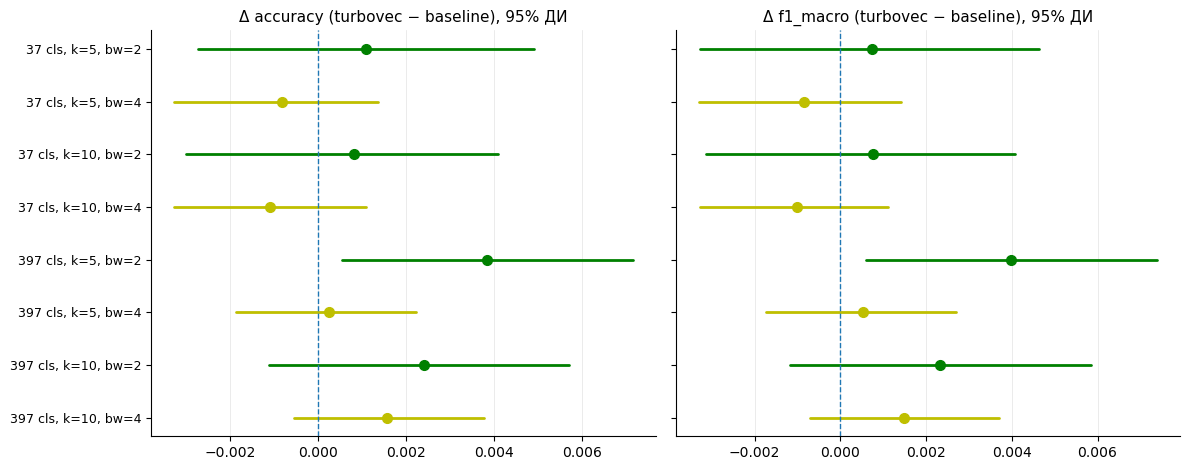

In [37]:
BW_COLORS = {2: "g", 4: "y"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, metric in zip(axes, ("accuracy", "f1_macro")):
    sub = boot_df[boot_df["metric"] == metric].sort_values(
        ["n_classes", "k", "bit_width"]).reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for i, row in sub.iterrows():
        color = BW_COLORS[row["bit_width"]]
        ax.plot([row["ci95_low"], row["ci95_high"]], [ypos[i]] * 2,
                color=color, lw=2, solid_capstyle="round")
        ax.plot(row["observed_diff_turbovec_minus_baseline"], ypos[i], "o", ms=7, color=color)
    ax.axvline(0, lw=1, ls="--")
    labels = (sub["n_classes"].astype(str) + " cls, k=" + sub["k"].astype(str)
              + ", bw=" + sub["bit_width"].astype(str))
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f"Δ {metric} (turbovec − baseline), 95% ДИ", fontsize=11)
    ax.grid(axis="x", alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## Вывод

Turbovec не ухудшает качество классификации изображений.

- По всем 16 сравнениям нет ни одной статистически значимой просадки
- Худшая наблюдаемая разница с baseline −0.0011
- McNemar не находит значимых ухудшений ни в одной конфигурации
- Top-5 accuracy сопоставима с baseline во всех конфигурациях.